# Regionalized LCIA with EDGES

This notebook calculates **location-dependent impacts** for the assessed PoR product system in CL and OCE. It complements notebook 3, which groups ordinary LCIA contributions by activity location. EDGES changes the characterization factors themselves before we group the results geographically.

The default indicators are AWARE 2.0 water scarcity (country, unspecified consumption), IMPACT World+ 2.1 particulate matter formation, and IMPACT World+ 2.1 terrestrial acidification. They have different units and are displayed in separate panels. The country grouping describes the **location of the contributing activity**, not the geographical distribution of affected people or ecosystems.

**First use:** rebuild `remind-transience_por.zip` using notebook 1 after the recent LCI edits, then set `RUN_CALCULATION = True` below. Start with 2025 and 2050 before expanding to every year. Existing ordinary `results_*.gzip` files cannot be converted into EDGES results. Later, set `RUN_CALCULATION = False` to load the separate EDGES export.

No Brightway database is created or modified by this notebook. Pathways manages its own cache and logs during calculation. Outputs use an `edges_por` prefix so they are separate from the figures in notebooks 2 and 3.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from importlib import metadata
import ast
import hashlib
import json
import re
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pycountry
import yaml
from IPython.display import display

ROOT = Path.cwd()
DATAPACKAGE = ROOT / "remind-transience_por.zip"
POR_CONFIG = ROOT / "configuration_file" / "config_itom_por.yaml"

RUN_CALCULATION = True
RESULTS_FILE = None  # Explicit EDGES .gzip file, or None for newest results_edges_por_*.gzip
CALCULATION_YEARS = [2025, 2050]  # Expand to [2025, 2030, ..., 2050] after the initial run.
SCENARIO_SELECTION = None  # None = all available scenarios, normally CL and OCE.
DEMAND_REGION = "NL"
EXTERNAL_MODULE = 1
EXCLUDED_ALIASES = {"FE_PBR"}  # Retain the obsolete-PBR exclusion used in notebook 2.
EXCLUDE_STANDALONE_CCS = True  # MTO storage service is embedded in the new product LCIs.

FOCUS_YEAR = 2050
TOP_COUNTRIES = 7
SAVE_OUTPUTS = True
OUTPUT_DIR = ROOT / "figs" / "edges_por"
REQUIRE_CURRENT_PACKAGE = True

METHODS = [
    ("AWARE 2.0", "Country", "unspecified", "yearly"),
    ("ImpactWorld+ 2.1", "Particulate matter formation", "midpoint"),
    ("ImpactWorld+ 2.1", "Terrestrial acidification", "midpoint"),
]
METHOD_TITLES = {
    ("AWARE 2.0", "Country", "unspecified", "yearly"): "Water scarcity · AWARE 2.0",
    ("ImpactWorld+ 2.1", "Particulate matter formation", "midpoint"): "Particulate matter · IMPACT World+",
    ("ImpactWorld+ 2.1", "Terrestrial acidification", "midpoint"): "Terrestrial acidification · IMPACT World+",
}
SCOPE_ORDER = [
    "NL-located activities",
    "Morocco-located activities",
    "Other explicitly foreign activities",
    "Aggregate / unresolved geography",
]
SCOPE_COLORS = {
    SCOPE_ORDER[0]: "#0072B2",
    SCOPE_ORDER[1]: "#CC79A7",
    SCOPE_ORDER[2]: "#D55E00",
    SCOPE_ORDER[3]: "#A6A6A6",
}
SCOPE_HATCHES = {scope: "////" if scope == SCOPE_ORDER[-1] else None for scope in SCOPE_ORDER}

## Method and geography checks

Your inspected environment contains Pathways 1.0.4 and EDGES 1.2.2. The installed Pathways adapter does not pass activity classifications to EDGES, so this notebook uses methods without classification-specific factors. AWARE's `unspecified` variant keeps country differentiation while avoiding unsupported agricultural/non-agricultural classification matching.

The default factors are **static regional factors**. Future results change with the scenario inventories and volumes; they do not automatically incorporate future climate, water-scarcity factors or population exposure. The geographic fallback strategies can characterize `RER`, `EUR`, `GLO` and `RoW`, but the Pathways export still labels contributions with their original activity location. Those contributions stay in an unresolved category.

References: [EDGES methods and matching rules](https://edges.readthedocs.io/en/stable/methods.html), [Pathways](https://github.com/polca/pathways). Method units and the presence of country-specific factors are read from the installed method files below. This declaration check is not an exchange-level CF-matching audit.

In [2]:
ISO_COUNTRIES = {country.alpha_2 for country in pycountry.countries}
ISO_COUNTRIES.add("XK")  # Kosovo is also used as an inventory location.

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def canonical_method(value):
    if isinstance(value, (tuple, list)):
        return tuple(map(str, value))
    try:
        parsed = ast.literal_eval(str(value))
    except (ValueError, SyntaxError):
        raise ValueError(f"Not an EDGES method tuple: {value!r}. Select an EDGES export.") from None
    if not isinstance(parsed, (tuple, list)) or not all(isinstance(x, str) for x in parsed):
        raise ValueError(f"Invalid EDGES method label: {value!r}")
    return tuple(parsed)

def classify_location(location):
    location = "" if pd.isna(location) else str(location).strip()
    parent = location.split("-", 1)[0]
    if location == "NL" or (parent == "NL" and "-" in location):
        return SCOPE_ORDER[0]
    if location == "MA" or (parent == "MA" and "-" in location):
        return SCOPE_ORDER[1]
    if location in ISO_COUNTRIES or ("-" in location and parent in ISO_COUNTRIES):
        return SCOPE_ORDER[2]
    return SCOPE_ORDER[3]

def scenario_label(value):
    match = re.search(r"(?:^|[- _])(CL|OCE)$", str(value))
    return match.group(1) if match else str(value)

def scenario_order(values):
    return sorted(set(map(str, values)), key=lambda x: ({"CL": 0, "OCE": 1}.get(scenario_label(x), 2), scenario_label(x)))

def active_por_aliases(config_path):
    config = yaml.safe_load(Path(config_path).read_text(encoding="utf-8"))
    aliases = {key for key in config["production pathways"] if str(key).startswith("FE_")}
    aliases -= EXCLUDED_ALIASES
    if EXCLUDE_STANDALONE_CCS:
        aliases = {key for key in aliases if not key.startswith("FE_CC_")}
    if not aliases:
        raise ValueError("No active PoR final-demand aliases selected.")
    return aliases

def select_demand_variables(values, aliases):
    prefix = f"EXT - {EXTERNAL_MODULE} - "
    selected = [str(value) for value in values
                if str(value).startswith(prefix) and str(value)[len(prefix):] in aliases]
    present = {value[len(prefix):] for value in selected}
    missing = aliases - present
    if missing:
        raise ValueError(f"Package lacks active PoR aliases {sorted(missing)}. Rebuild notebook 1.")
    return selected

def check_package_freshness(package):
    package = Path(package)
    if not package.exists():
        raise FileNotFoundError(f"{package.name} is missing. Build the PoR package with notebook 1.")
    relevant = [POR_CONFIG, ROOT / "inventories" / "lci-itom_por.xlsx",
                ROOT / "scenario_data" / "scenario_data_itom_por.csv"]
    newer = [path for path in relevant if path.exists() and path.stat().st_mtime > package.stat().st_mtime]
    if newer and REQUIRE_CURRENT_PACKAGE:
        names = ", ".join(str(path.relative_to(ROOT)) for path in newer)
        raise RuntimeError(f"The PoR ZIP is older than {names}. Rebuild notebook 1 before EDGES calculation.")
    return newer

def validate_results(frame, methods, aliases):
    required = {"act_category", "variable", "year", "region", "location", "model",
                "scenario", "impact_category", "value"}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"Missing result columns: {sorted(missing)}")
    if "quantile" in frame.columns:
        raise ValueError("Use deterministic results here. Contribution quantiles cannot be added to obtain total quantiles.")
    out = frame.copy()
    out["method"] = out["impact_category"].map(canonical_method)
    unknown = set(out["method"]) - set(methods)
    if unknown:
        print("Methods outside the current selection are excluded:", sorted(unknown))
    out = out.loc[out["method"].isin(methods) & out["region"].eq(DEMAND_REGION)].copy()
    prefix = f"EXT - {EXTERNAL_MODULE} - "
    allowed = {prefix + alias for alias in aliases}
    removed = sorted(set(out["variable"]) - allowed)
    if removed:
        print("Variables outside the current PoR demand boundary are excluded:", removed)
    out = out.loc[out["variable"].isin(allowed)].copy()
    if SCENARIO_SELECTION is not None:
        out = out.loc[out["scenario"].isin(SCENARIO_SELECTION)].copy()
    if out.empty:
        raise ValueError("No EDGES contributions remain after method, scenario and PoR-demand selection.")
    out["value"] = pd.to_numeric(out["value"], errors="raise")
    if not np.isfinite(out["value"].to_numpy()).all():
        raise ValueError("Results contain non-finite values.")
    out["year"] = pd.to_numeric(out["year"], errors="raise").astype(int)
    if out["model"].nunique() != 1:
        raise ValueError("Select one IAM model; this notebook does not add results from different models.")
    missing_methods = set(methods) - set(out["method"])
    if missing_methods:
        raise ValueError(f"No exported contributions for {sorted(missing_methods)}. Check method matching or select fewer methods.")
    keys = ["act_category", "variable", "year", "region", "location", "model", "scenario", "method"]
    if out.duplicated(keys).any():
        raise ValueError("Duplicate result coordinates found; do not concatenate overlapping runs.")
    labels = out[["scenario"]].drop_duplicates()
    if labels["scenario"].map(scenario_label).duplicated().any():
        raise ValueError("Scenario display labels collide. Select one CL and one OCE pathway, or revise scenario_label().")
    out["scope"] = out["location"].map(classify_location)
    out["positive"] = out["value"].clip(lower=0)
    out["negative"] = out["value"].clip(upper=0)
    out["absolute"] = out["value"].abs()
    return out

def aggregate_geography(frame):
    keys = ["scenario", "year", "method"]
    grouped = frame.groupby(keys + ["scope"], as_index=False, observed=True, dropna=False).agg(
        value=("value", "sum"), positive=("positive", "sum"),
        negative=("negative", "sum"), absolute=("absolute", "sum"))
    expected = frame.groupby(keys, observed=True, dropna=False)["value"].sum().sort_index()
    actual = grouped.groupby(keys, observed=True, dropna=False)["value"].sum().reindex(expected.index)
    np.testing.assert_allclose(actual.to_numpy(), expected.to_numpy(), rtol=1e-10, atol=1e-10)
    np.testing.assert_allclose(grouped["positive"] + grouped["negative"], grouped["value"], rtol=1e-10, atol=1e-10)
    totals = frame.groupby(keys, as_index=False, observed=True).agg(
        net_total=("value", "sum"), positive_total=("positive", "sum"),
        negative_total=("negative", "sum"), absolute_total=("absolute", "sum"))
    denominator = grouped.groupby(keys, observed=True)["absolute"].transform("sum")
    grouped["absolute_share"] = np.divide(
        grouped["absolute"], denominator,
        out=np.full(len(grouped), np.nan), where=denominator.to_numpy() > 0)
    return grouped, totals

def make_layout(frame):
    layout = frame[["scenario", "year"]].drop_duplicates().copy()
    ordering = scenario_order(layout["scenario"])
    layout["scenario"] = pd.Categorical(layout["scenario"], categories=ordering, ordered=True)
    layout = layout.sort_values(["scenario", "year"]).reset_index(drop=True)
    layout["scenario"] = layout["scenario"].astype(object)
    layout["x"] = np.arange(len(layout))
    return layout

def make_location_table(frame, method, year, top_n=7):
    focus = frame.loc[frame["method"].isin([method]) & frame["year"].eq(year)].copy()
    if focus.empty:
        return pd.DataFrame()
    explicit = focus.loc[focus["scope"].ne(SCOPE_ORDER[-1])]
    ranks = explicit.groupby("location", observed=True)["absolute"].sum().sort_values(ascending=False)
    pinned = [location for location in ("NL", "MA") if location in set(explicit["location"])]
    remaining = [location for location in ranks.index if location not in pinned][:top_n]
    selected = pinned + remaining
    def bucket(row):
        if row["scope"] == SCOPE_ORDER[-1]:
            return "Aggregate / unresolved"
        return row["location"] if row["location"] in selected else "Other explicit locations"
    focus["display_location"] = focus.apply(bucket, axis=1)
    locations = selected + ["Other explicit locations", "Aggregate / unresolved"]
    table = focus.groupby(["display_location", "scenario"], observed=True)["value"].sum().unstack("scenario", fill_value=0)
    table = table.reindex(index=[key for key in locations if key in table.index],
                          columns=scenario_order(focus["scenario"]), fill_value=0)
    np.testing.assert_allclose(table.sum().to_numpy(),
                               focus.groupby("scenario")["value"].sum().reindex(table.columns).to_numpy(),
                               rtol=1e-10, atol=1e-10)
    return table

## Calculate or load a dedicated EDGES export

Keep the **demand region** at NL. This selects assessed PoR product demand and still includes the worldwide supply chain. Geographic aggregation is deliberately performed after EDGES characterization.

A fresh Pathways object is created only when calculation is enabled. Ordinary `methods=` is omitted because Pathways accepts either ordinary methods or `edges_methods=` in a call. Deterministic calculations and both multiprocessing options are set explicitly.

New exports include a JSON provenance file with package, inventory, config and method hashes. Loading an older export reports differences from current inputs; it does not silently relabel it as a calculation of today's inventories.

In [3]:
from edges import get_available_methods
from edges.filesystem_constants import DATA_DIR as EDGES_DATA_DIR

available_methods = get_available_methods()
unavailable = set(METHODS) - set(available_methods)
if unavailable:
    raise ValueError(f"Methods not installed: {sorted(unavailable)}. Inspect get_available_methods().")

method_info = {}
for method in METHODS:
    method_path = Path(EDGES_DATA_DIR) / ("_".join(method) + ".json")
    raw_method = json.loads(method_path.read_text(encoding="utf-8"))
    factors = raw_method["exchanges"]
    classified_rows = sum("classifications" in factor.get("consumer", {}) for factor in factors)
    supplier_matrices = {factor["supplier"]["matrix"] for factor in factors}
    if classified_rows:
        raise ValueError(f"{method} needs classification-aware matching. Use AWARE unspecified or review the Pathways adapter.")
    if supplier_matrices != {"biosphere"}:
        raise ValueError(f"{method} uses technosphere or mixed edge families. This notebook validates biosphere regionalization only.")
    if not raw_method.get("unit"):
        raise ValueError(f"No declared unit for {method}.")
    method_info[method] = {
        "unit": raw_method["unit"],
        "cf_rows": len(factors),
        "country_locations": {factor.get("consumer", {}).get("location") for factor in factors
                              if factor.get("consumer", {}).get("location")},
        "class_sensitive_rows": classified_rows,
        "sha256": sha256_file(method_path),
    }

display(pd.DataFrame([
    {"Method": METHOD_TITLES.get(method, " / ".join(method)),
     "Unit": info["unit"], "CF rows": info["cf_rows"],
     "MA-specific rows": "MA" in info["country_locations"],
     "NL-specific rows": "NL" in info["country_locations"],
     "Classification-specific rows": info["class_sensitive_rows"]}
    for method, info in method_info.items()
]))
print("Installed versions:", {name: metadata.version(name) for name in ("pathways", "edges")})
aliases = active_por_aliases(POR_CONFIG)
results_path = None
provenance = None
df_edges = None
source_files = [POR_CONFIG, ROOT / "inventories" / "lci-itom_por.xlsx",
                ROOT / "scenario_data" / "scenario_data_itom_por.csv"]

if RUN_CALCULATION:
    check_package_freshness(DATAPACKAGE)
    from pathways import Pathways
    p_edges = Pathways(datapackage=str(DATAPACKAGE), ecoinvent_version="3.12", debug=True)

    p_edges.units['Mt Crude steel'] = {'kilogram': '1e+9'}
    p_edges.units['Mt/year'] = {'kilogram': '1e+9'}
    p_edges.units['kt/year'] = {'kilogram': '1e+6'}
    p_edges.units['kt/yr'] = {'kilogram': '1e+6'}

    selected_variables = select_demand_variables(p_edges.scenarios.coords["variables"].values, aliases)
    available_years = set(map(int, p_edges.scenarios.coords["year"].values))
    if not set(CALCULATION_YEARS) <= available_years:
        raise ValueError(f"Calculation years unavailable. Package years: {sorted(available_years)}")
    selected_scenarios = (list(map(str, p_edges.scenarios.coords["pathway"].values))
                          if SCENARIO_SELECTION is None else list(SCENARIO_SELECTION))
    missing_scenarios = set(selected_scenarios) - set(map(str, p_edges.scenarios.coords["pathway"].values))
    if missing_scenarios:
        raise ValueError(f"Scenarios unavailable: {sorted(missing_scenarios)}")
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    export_base = ROOT / f"results_edges_por_{timestamp}"
    provenance = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "versions": {name: metadata.version(name) for name in ("pathways", "edges")},
        "datapackage": DATAPACKAGE.name, "datapackage_sha256": sha256_file(DATAPACKAGE),
        "source_sha256": {str(path.relative_to(ROOT)): sha256_file(path) for path in source_files if path.exists()},
        "methods": [list(method) for method in METHODS],
        "method_sha256": {str(method): info["sha256"] for method, info in method_info.items()},
        "scenarios": selected_scenarios, "years": CALCULATION_YEARS,
        "variables": selected_variables, "demand_region": DEMAND_REGION,
        "excluded_aliases": sorted(EXCLUDED_ALIASES),
        "exclude_standalone_ccs": EXCLUDE_STANDALONE_CCS,
        "characterization": "Static regional factors; prospective inventories",
    }
    p_edges.calculate(
        edges_methods=METHODS,
        regions=[DEMAND_REGION],
        scenarios=selected_scenarios,
        years=CALCULATION_YEARS,
        variables=selected_variables,
        use_distributions=0,
        multiprocessing=False,
        postprocess_multiprocessing=False,
    )
    # Export the unthresholded array: do not collapse small locations with aggregate_results().
    results_path = Path(p_edges.export_results(filename=str(export_base)))
    results_path.with_suffix(".json").write_text(json.dumps(provenance, indent=2), encoding="utf-8")
else:
    if RESULTS_FILE is not None:
        results_path = Path(RESULTS_FILE)
        if not results_path.is_absolute():
            results_path = ROOT / results_path
    else:
        candidates = sorted(ROOT.glob("results_edges_por_*.gzip"),
                            key=lambda path: path.stat().st_mtime, reverse=True)
        if candidates:
            results_path = candidates[0]

if results_path is not None:
    if not results_path.exists():
        raise FileNotFoundError(results_path)
    provenance_path = results_path.with_suffix(".json")
    if provenance is None and provenance_path.exists():
        provenance = json.loads(provenance_path.read_text(encoding="utf-8"))
    if provenance:
        package_digest = provenance.get("datapackage_sha256")
        if package_digest and DATAPACKAGE.exists() and sha256_file(DATAPACKAGE) != package_digest:
            warnings.warn("Loaded EDGES export uses a different PoR ZIP from the current package.")
        changed_inputs = [name for name, digest in provenance.get("source_sha256", {}).items()
                          if not (ROOT / name).exists() or sha256_file(ROOT / name) != digest]
        if changed_inputs:
            warnings.warn("Loaded EDGES export predates changes in: " + ", ".join(changed_inputs))
        changed_methods = [str(method) for method, info in method_info.items()
                           if provenance.get("method_sha256", {}).get(str(method)) != info["sha256"]]
        if changed_methods:
            warnings.warn("Installed CF files differ from the loaded result provenance: " + ", ".join(changed_methods))
    else:
        warnings.warn("This EDGES export has no provenance JSON. Its exact source-inventory version cannot be verified.")
    df_edges = validate_results(pd.read_parquet(results_path, engine="pyarrow"), METHODS, aliases)
    display(pd.Series({
        "EDGES results": results_path.name,
        "Rows in selected boundary": len(df_edges),
        "Scenarios": ", ".join(scenario_order(df_edges["scenario"])),
        "Years": ", ".join(map(str, sorted(df_edges["year"].unique()))),
        "Demand aliases": ", ".join(sorted(aliases)),
        "Demand region": DEMAND_REGION,
    }, name="Value").to_frame())
else:
    print("No EDGES result export found. Rebuild notebook 1, set RUN_CALCULATION=True, then run this notebook.")
    print("Ordinary results_*.gzip files are intentionally not loaded for regionalized LCIA.")

c:\Users\terlouw_t\.conda\envs\premise_pathways\Lib\site-packages\bw2calc\__init__.py:58: UserWarning: No fast sparse solver found
  warnings.warn("No fast sparse solver found")


,Method,Unit,CF rows,MA-specific rows,NL-specific rows,Classification-specific rows
0,Water scarcity · AWARE 2.0,m3 deprived water-eq.,3390,True,True,0
1,Particulate matter · IMPACT World+,kg PM2.5 eq,12612,True,True,0
2,Terrestrial acidification · IMPACT World+,kg SO2 eq,21732,True,True,0


Installed versions: {'pathways': '1.0.4', 'edges': '1.2.2'}


c:\Users\terlouw_t\.conda\envs\premise_pathways\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


18:18:36+0200 [warning  ] Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.


...

Geomatcher: Used 'RU' for 'IAI Area, Russia and Eastern Europe'
Geomatcher: Used 'RU' for 'IAI Area, Russia and Eastern Europe'


Resolving global locations    [5/5]
Fallback follow-up: 0 edge(s) were resolved later; 315166 edge(s) remain unmatched.


0% [#] 100% | ETA: 00:00:00
Total time elapsed: 00:07:14


Results exported to c:\Users\terlouw_t\Documents\Projects\TRANSIENCE\lca_transience\results_edges_por_20261008_181908.gzip


,Value
EDGES results,results_edges_por_20261008_181908.gzip
Rows in selected boundary,138919
Scenarios,"SSP2-PkBudg1000 - fc_nz - CL, SSP2-PkBudg1000 ..."
Years,"2025, 2050"
Demand aliases,"FE_MDI, FE_PBS, FE_PET, FE_PLA, FE_PMMA, FE_PP..."
Demand region,NL


## Geographic attribution and sign checks

NL-located contributions include PoR activities and other Dutch background activities. Morocco is shown separately because it is the assumed DAC-methanol production origin. Other explicit country/subnational locations are foreign; regional and global labels stay unresolved.

Positive and negative values are separated **before** geographic aggregation. This retains, for example, a positive water-withdrawal contribution and a negative water-return contribution occurring in the same geographic group. Negative values are signed LCIA contributions; they are not automatically CCS credits or removals. Absolute shares use the sum of absolute **exported rows**, not the absolute value of a net geographic total. Cancellation within a Pathways activity-category/location row cannot be recovered from this export.

A factor being declared for MA does not relocate RER/RoW water suppliers to Morocco. Review supply geography before interpreting national water-scarcity results.

In [4]:
scope_df = total_df = location_audit = None
if df_edges is not None:
    if FOCUS_YEAR not in set(df_edges["year"]):
        raise ValueError(f"FOCUS_YEAR={FOCUS_YEAR} is unavailable. Loaded years: {sorted(df_edges['year'].unique())}")
    scope_df, total_df = aggregate_geography(df_edges)
    location_audit = df_edges[["location", "scope"]].drop_duplicates().sort_values(["scope", "location"])
    for method in METHODS:
        location_audit[METHOD_TITLES.get(method, " / ".join(method)) + " · exact CF location declared"] = (
            location_audit["location"].isin(method_info[method]["country_locations"]))
    display(location_audit.reset_index(drop=True).head(30))
    summary = total_df.loc[total_df["year"].eq(FOCUS_YEAR)].copy()
    summary["scenario"] = summary["scenario"].map(scenario_label)
    summary["indicator"] = summary["method"].map(lambda method: METHOD_TITLES.get(method, " / ".join(method)))
    summary["unit"] = summary["method"].map(lambda method: method_info[method]["unit"])
    display(summary[["scenario", "year", "indicator", "unit", "net_total",
                     "positive_total", "negative_total", "absolute_total"]].reset_index(drop=True))

,location,scope,Water scarcity · AWARE 2.0 · exact CF location declared,Particulate matter · IMPACT World+ · exact CF location declared,Terrestrial acidification · IMPACT World+ · exact CF location declared
0,APAC,Aggregate / unresolved geography,False,False,False
1,Asia without China,Aggregate / unresolved geography,False,False,False
2,CAZ,Aggregate / unresolved geography,False,False,False
3,CHA,Aggregate / unresolved geography,False,False,False
4,Canada without Quebec,Aggregate / unresolved geography,False,False,False
5,EUR,Aggregate / unresolved geography,False,False,False
6,Europe without Austria,Aggregate / unresolved geography,False,False,False
7,Europe without Switzerland,Aggregate / unresolved geography,False,False,False
8,GLO,Aggregate / unresolved geography,False,False,False
9,"IAI Area, Africa",Aggregate / unresolved geography,False,False,False


,scenario,year,indicator,unit,net_total,positive_total,negative_total,absolute_total
0,CL,2050,Water scarcity · AWARE 2.0,m3 deprived water-eq.,3.062480e+11,3.085913e+11,-2.343328e+09,3.109346e+11
1,CL,2050,Particulate matter · IMPACT World+,kg PM2.5 eq,8.181543e+05,8.182032e+05,-4.890348e+01,8.182521e+05
2,CL,2050,Terrestrial acidification · IMPACT World+,kg SO2 eq,1.290802e+07,1.290839e+07,-3.666476e+02,1.290876e+07
3,OCE,2050,Water scarcity · AWARE 2.0,m3 deprived water-eq.,6.122378e+11,6.193699e+11,-7.132096e+09,6.265020e+11
4,OCE,2050,Particulate matter · IMPACT World+,kg PM2.5 eq,1.504775e+06,1.504816e+06,-4.071314e+01,1.504857e+06
5,OCE,2050,Terrestrial acidification · IMPACT World+,kg SO2 eq,2.053471e+07,2.053532e+07,-6.170431e+02,2.053594e+07


In [5]:
mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 8, "axes.titlesize": 10, "axes.labelsize": 8,
    "axes.linewidth": 0.7, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "legend.frameon": False,
    "figure.dpi": 130, "savefig.dpi": 300, "pdf.fonttype": 42, "ps.fonttype": 42,
})
scope_handles = [Patch(facecolor=SCOPE_COLORS[scope], edgecolor="white",
                       hatch=SCOPE_HATCHES[scope], label=scope) for scope in SCOPE_ORDER]
net_handle = mpl.lines.Line2D([], [], color="#222222", marker="o", markersize=3,
                             linewidth=0, label="Net total")

def choose_scale(values, unit):
    unit = {"m3 deprived water-eq.": "m$^3$ deprived water-eq.",
            "kg PM2.5 eq": "kg PM$_{2.5}$-eq.",
            "kg SO2 eq": "kg SO$_2$-eq."}.get(unit, unit)
    maximum = np.max(np.abs(np.asarray(values, dtype=float))) if len(values) else 0
    for factor in (1e9, 1e6, 1e3):
        if maximum >= factor:
            return factor, f"{unit} × 10$^{{{int(np.log10(factor))}}}$"
    return 1.0, unit

def add_scenario_blocks(ax, layout):
    for index, scenario in enumerate(scenario_order(layout["scenario"])):
        positions = layout.loc[layout["scenario"].eq(scenario), "x"]
        ax.text(float(positions.mean()), 1.02, textwrap.fill(scenario_label(scenario), 22),
                transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                fontweight="bold", fontsize=9)
        if index:
            ax.axvline(float(positions.min()) - 0.5, color="#777777", linewidth=0.7)
    ax.set_xlim(-0.6, max(layout["x"]) + 0.6)
    ax.set_xticks(layout["x"], layout["year"].astype(str), rotation=90)

def draw_signed_stacks(ax, x, positive, negative):
    upper = np.zeros(len(x))
    lower = np.zeros(len(x))
    for scope in SCOPE_ORDER:
        pos = positive[scope].to_numpy()
        neg = negative[scope].to_numpy()
        options = dict(width=0.72, color=SCOPE_COLORS[scope], hatch=SCOPE_HATCHES[scope],
                       edgecolor="white", linewidth=0.35, zorder=2)
        ax.bar(x, pos, bottom=upper, **options)
        ax.bar(x, neg, bottom=lower, **options)
        upper += pos
        lower += neg
    return upper, lower

def save_figure(fig, stem):
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        for extension in ("png", "pdf"):
            fig.savefig(OUTPUT_DIR / f"{stem}.{extension}", bbox_inches="tight")
    return fig

def plot_regional_totals(grouped, methods, units):
    layout = make_layout(grouped)
    index = pd.MultiIndex.from_frame(layout[["scenario", "year"]])
    fig, axes = plt.subplots(len(methods), 1, figsize=(max(7.2, 0.48 * len(layout)), 3.1 * len(methods)),
                             squeeze=False)
    for panel, (ax, method) in enumerate(zip(axes.flat, methods)):
        subset = grouped.loc[grouped["method"].isin([method])]
        pos = subset.pivot(index=["scenario", "year"], columns="scope", values="positive").reindex(index)
        neg = subset.pivot(index=["scenario", "year"], columns="scope", values="negative").reindex(index)
        valid = pos.notna().any(axis=1).to_numpy()
        pos = pos.reindex(columns=SCOPE_ORDER).fillna(0)
        neg = neg.reindex(columns=SCOPE_ORDER).fillna(0)
        scale, ylabel = choose_scale(np.r_[pos.sum(axis=1), neg.sum(axis=1)], units[method])
        upper, lower = draw_signed_stacks(ax, layout["x"].to_numpy(), pos / scale, neg / scale)
        total = (pos.sum(axis=1) + neg.sum(axis=1)).to_numpy() / scale
        ax.scatter(layout.loc[valid, "x"], total[valid], color="#222222", s=11, zorder=4)
        for x in layout.loc[~valid, "x"]:
            ax.text(x, 0, "n/a", ha="center", va="bottom", fontsize=6)
        add_scenario_blocks(ax, layout)
        ax.axhline(0, color="#333333", linewidth=0.7)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{chr(97 + panel)}  {METHOD_TITLES.get(method, ' / '.join(method))}", loc="left", pad=29)
        ax.grid(axis="y", color="#DDDDDD", linewidth=0.5)
        ax.set_axisbelow(True)
        ax.margins(y=0.12)
        ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(5))
    axes.flat[-1].set_xlabel("Year")
    fig.legend(handles=scope_handles + [net_handle], loc="lower center", ncol=3,
               bbox_to_anchor=(0.5, 0.005))
    fig.subplots_adjust(left=0.12, right=0.98, top=0.89, bottom=0.10, hspace=0.60)
    fig.suptitle("Regionalized impacts of assessed PoR products", y=0.995, fontsize=11, fontweight="bold")
    return fig

def plot_composition(grouped, methods, year):
    focus = grouped.loc[grouped["year"].eq(year)]
    rows = [(scenario, method) for scenario in scenario_order(focus["scenario"]) for method in methods]
    layout = pd.DataFrame(rows, columns=["scenario", "method"])
    layout["x"] = np.arange(len(layout))
    index = pd.MultiIndex.from_frame(layout[["scenario", "method"]])
    shares = focus.pivot(index=["scenario", "method"], columns="scope", values="absolute_share")
    shares = shares.reindex(index=index, columns=SCOPE_ORDER)
    valid = shares.notna().any(axis=1).to_numpy()
    fig, ax = plt.subplots(figsize=(max(7.2, 0.9 * len(layout)), 3.8))
    bottom = np.zeros(len(layout))
    for scope in SCOPE_ORDER:
        values = shares[scope].fillna(0).to_numpy()
        ax.bar(layout["x"], values, bottom=bottom, width=0.72, color=SCOPE_COLORS[scope],
               hatch=SCOPE_HATCHES[scope], edgecolor="white", linewidth=0.35)
        for x, value, base in zip(layout["x"], values, bottom):
            if value >= 0.08:
                ax.text(x, base + value / 2, f"{value:.0%}", ha="center", va="center",
                        fontsize=7, color="#222222" if scope == SCOPE_ORDER[-1] else "white")
        bottom += values
    for index_s, scenario in enumerate(scenario_order(layout["scenario"])):
        positions = layout.loc[layout["scenario"].eq(scenario), "x"]
        ax.text(float(positions.mean()), 1.03, scenario_label(scenario), transform=ax.get_xaxis_transform(),
                ha="center", fontweight="bold", fontsize=9)
        if index_s:
            ax.axvline(float(positions.min()) - 0.5, color="#777777", linewidth=0.7)
    for x in layout.loc[~valid, "x"]:
        ax.text(x, 0.5, "n/a", ha="center")
    short_titles = {
        ("AWARE 2.0", "Country", "unspecified", "yearly"): "Water scarcity",
        ("ImpactWorld+ 2.1", "Particulate matter formation", "midpoint"): "Particulate matter",
        ("ImpactWorld+ 2.1", "Terrestrial acidification", "midpoint"): "Acidification",
    }
    ax.set_xticks(layout["x"], [textwrap.fill(short_titles.get(method, " / ".join(method)), 18)
                                for method in layout["method"]])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of absolute exported contributions")
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1))
    ax.set_title(f"Geographic composition in {year}", loc="left", pad=32, fontweight="bold")
    fig.legend(handles=scope_handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0))
    fig.subplots_adjust(left=0.10, right=0.98, top=0.80, bottom=0.27)
    return fig

def country_display(location):
    if str(location) in ISO_COUNTRIES:
        country = pycountry.countries.get(alpha_2=location)
        return f"{location} · {getattr(country, 'name', location)}"
    return str(location)

def plot_locations(frame, methods, units, year):
    fig, axes = plt.subplots(1, len(methods), figsize=(4.3 * len(methods), 4.5), squeeze=False)
    scenarios = scenario_order(frame["scenario"])
    cmap = plt.get_cmap("tab10")
    colors = {scenario: cmap(i % 10) for i, scenario in enumerate(scenarios)}
    handles = [Patch(facecolor=colors[scenario], label=scenario_label(scenario)) for scenario in scenarios]
    for panel, (ax, method) in enumerate(zip(axes.flat, methods)):
        table = make_location_table(frame, method, year, TOP_COUNTRIES)
        if table.empty:
            ax.set_visible(False)
            continue
        table = table.reindex(columns=scenarios, fill_value=0)
        scale, unit = choose_scale(table.to_numpy().ravel(), units[method])
        y = np.arange(len(table))
        width = 0.74 / max(len(scenarios), 1)
        for i, scenario in enumerate(scenarios):
            offset = (i - (len(scenarios) - 1) / 2) * width
            ax.barh(y + offset, table[scenario] / scale, height=width,
                    color=colors[scenario], linewidth=0.3, edgecolor="white")
        ax.set_yticks(y, [textwrap.fill(country_display(location), 24) for location in table.index])
        ax.invert_yaxis()
        ax.axvline(0, color="#444444", linewidth=0.6)
        ax.grid(axis="x", color="#DDDDDD", linewidth=0.5)
        ax.set_axisbelow(True)
        ax.set_xlabel(unit)
        ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
        ax.set_title(f"{chr(97 + panel)}  {textwrap.fill(METHOD_TITLES.get(method, ' / '.join(method)), 30)}",
                     loc="left", pad=10)
    fig.suptitle(f"Contributions by activity location in {year}", y=1.01, fontsize=11, fontweight="bold")
    fig.legend(handles=handles, loc="lower center", ncol=max(1, len(scenarios)), bbox_to_anchor=(0.5, -0.04))
    fig.tight_layout(rect=(0, 0.06, 1, 0.97))
    return fig

def plot_scenario_difference(grouped, methods, units, year):
    focus = grouped.loc[grouped["year"].eq(year)].copy()
    lookup = {scenario_label(scenario): scenario for scenario in focus["scenario"].unique()}
    if not {"CL", "OCE"} <= set(lookup):
        return None, pd.DataFrame()
    rows = []
    fig, axes = plt.subplots(1, len(methods), figsize=(4.0 * len(methods), 3.5), squeeze=False)
    for panel, (ax, method) in enumerate(zip(axes.flat, methods)):
        subset = focus.loc[focus["method"].isin([method])]
        if not {lookup["CL"], lookup["OCE"]} <= set(subset["scenario"]):
            ax.set_visible(False)
            continue
        table = subset.pivot(index="scope", columns="scenario", values="value").reindex(SCOPE_ORDER).fillna(0)
        difference = table[lookup["OCE"]] - table[lookup["CL"]]
        scale, unit = choose_scale(difference.to_numpy(), units[method])
        ax.barh(np.arange(len(SCOPE_ORDER)), difference / scale,
                color=[SCOPE_COLORS[scope] for scope in SCOPE_ORDER], height=0.65)
        ax.set_yticks(np.arange(len(SCOPE_ORDER)), [textwrap.fill(scope, 23) for scope in SCOPE_ORDER])
        ax.invert_yaxis()
        ax.axvline(0, color="#333333", linewidth=0.7)
        ax.grid(axis="x", color="#DDDDDD", linewidth=0.5)
        ax.set_axisbelow(True)
        ax.set_xlabel(f"OCE − CL [{unit}]")
        ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
        ax.set_title(f"{chr(97 + panel)}  {textwrap.fill(METHOD_TITLES.get(method, ' / '.join(method)), 30)}",
                     loc="left", pad=9)
        baseline = table[lookup["CL"]].sum()
        delta = difference.sum()
        relative = delta / baseline * 100 if baseline > 0 else np.nan
        rows.append({"method": str(method), "year": year, "unit": units[method],
                     "CL": baseline, "OCE": table[lookup["OCE"]].sum(), "OCE_minus_CL": delta,
                     "change_percent_of_positive_CL": relative})
    fig.suptitle(f"Regional contribution to the OCE − CL difference in {year}", fontsize=11,
                 fontweight="bold", y=1.02)
    fig.tight_layout()
    return fig, pd.DataFrame(rows)

## Figure 1 — Regionalized impacts through time

Each panel has its own indicator and unit. CL and OCE appear in the same axes, separated by a line and labeled in bold above their year blocks. Positive and negative exported contributions are stacked separately; the black dot is the net total. An absent scenario/year/method combination is marked `n/a` rather than assigned a zero score.

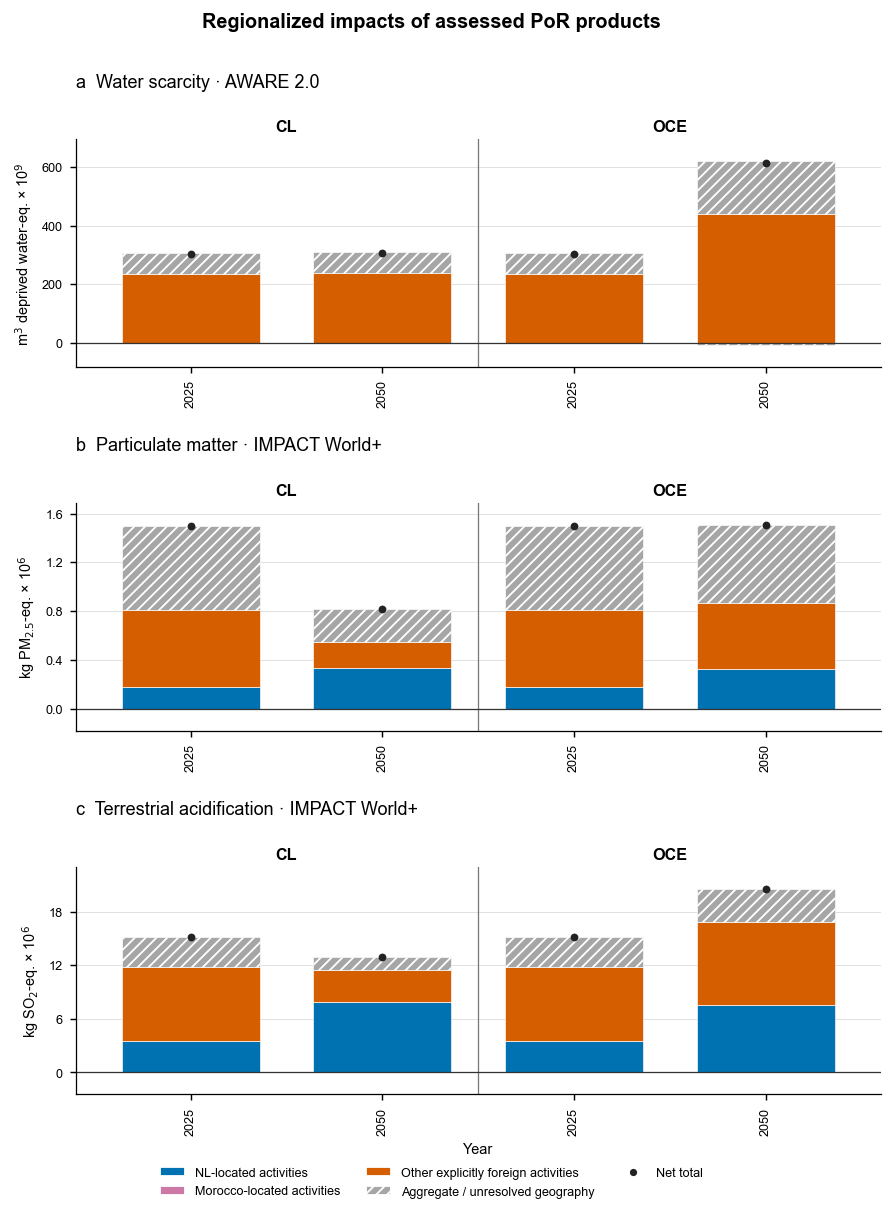

In [6]:
if scope_df is not None:
    units = {method: info["unit"] for method, info in method_info.items()}
    fig = plot_regional_totals(scope_df, METHODS, units)
    save_figure(fig, "edges_por_regional_impacts_over_time")
    plt.show()

## Figure 2 — Geographic composition

This figure compares shares of absolute exported contributions within each indicator in the focus year. It is not a comparison of numerical impact magnitudes between indicators, and it is not a percentage of net emissions. Opposite-sign contributions are retained in the denominator before geographic grouping.

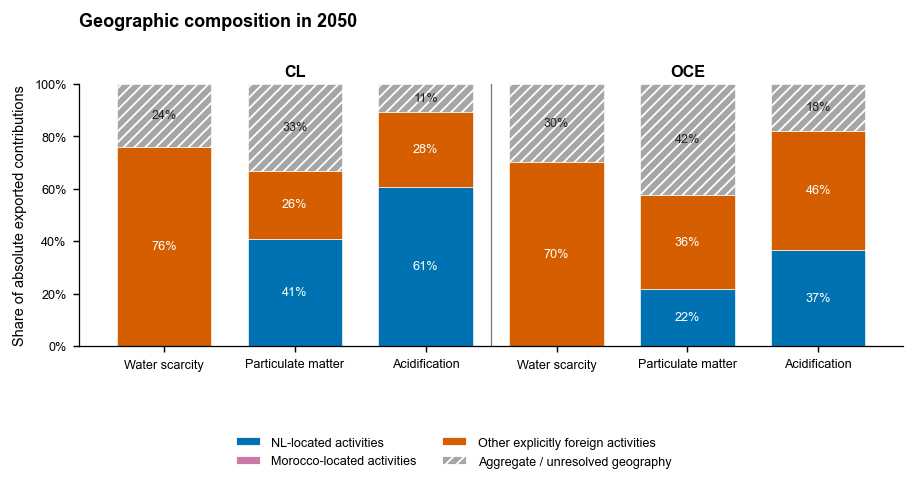

In [7]:
if scope_df is not None:
    fig = plot_composition(scope_df, METHODS, FOCUS_YEAR)
    save_figure(fig, f"edges_por_geographic_composition_{FOCUS_YEAR}")
    plt.show()

## Figure 3 — Activity-location contributions

NL and MA are retained when present. Other large explicit locations are selected using absolute exported contributions, with the remainder combined into an explicit-location bucket. Aggregate/unresolved geographies are shown separately. These buckets preserve each scenario's total for each indicator; they do not claim that an aggregate factor has identified the underlying emission country.

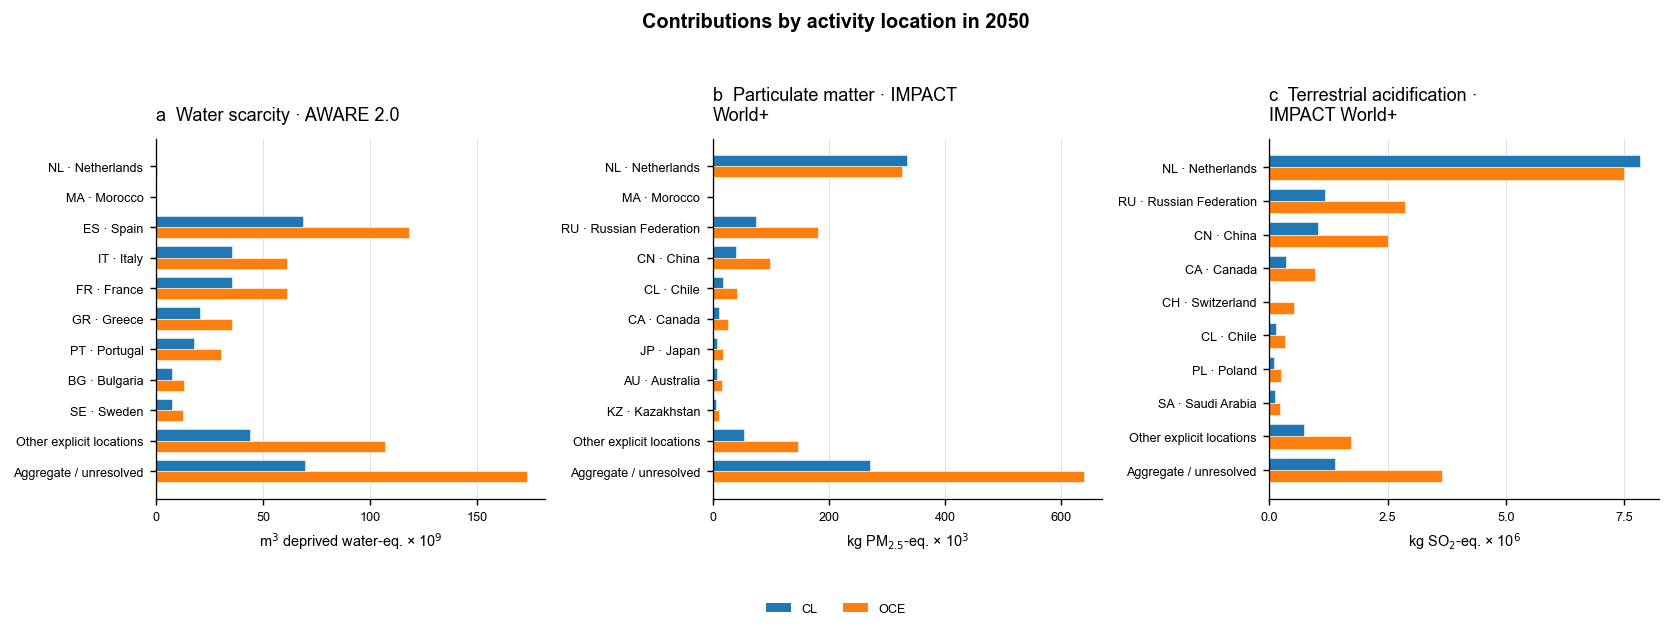

In [8]:
if df_edges is not None:
    fig = plot_locations(df_edges, METHODS, units, FOCUS_YEAR)
    save_figure(fig, f"edges_por_activity_locations_{FOCUS_YEAR}")
    plt.show()

## Figure 4 — Contributions to the scenario difference

For each indicator, the figure shows the geographic contribution to **OCE minus CL**. Positive values mean a higher characterized burden in OCE for that geographic group. Relative changes are reported only when the CL net baseline is positive. The figure is skipped when both CL and OCE are not present.

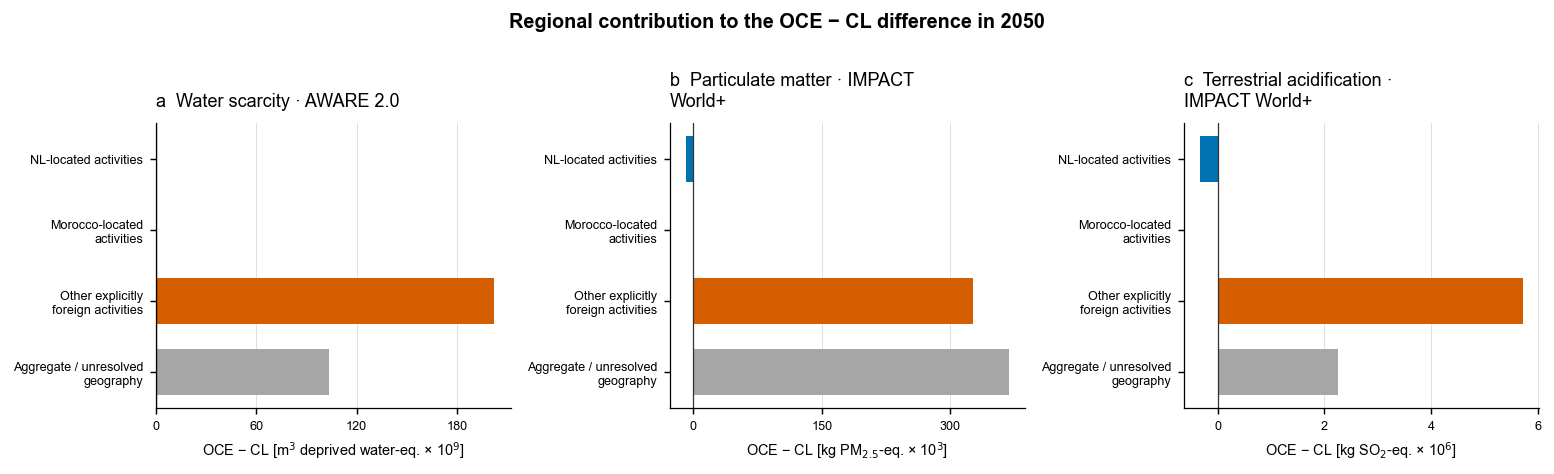

,method,year,unit,CL,OCE,OCE_minus_CL,change_percent_of_positive_CL
0,"('AWARE 2.0', 'Country', 'unspecified', 'yearly')",2050,m3 deprived water-eq.,3.062480e+11,6.122378e+11,3.059898e+11,99.915708
1,"('ImpactWorld+ 2.1', 'Particulate matter forma...",2050,kg PM2.5 eq,8.181543e+05,1.504775e+06,6.866211e+05,83.923181
2,"('ImpactWorld+ 2.1', 'Terrestrial acidificatio...",2050,kg SO2 eq,1.290802e+07,2.053471e+07,7.626681e+06,59.084807


In [9]:
difference_table = None
if scope_df is not None:
    fig, difference_table = plot_scenario_difference(scope_df, METHODS, units, FOCUS_YEAR)
    if fig is not None:
        save_figure(fig, f"edges_por_oce_minus_cl_{FOCUS_YEAR}")
        plt.show()
        display(difference_table)
    else:
        print("OCE − CL figure skipped: both scenario labels are required.")

## Export tables and interpretation

The tables retain units and full EDGES method identifiers. The geographic and scenario comparisons use the same selected final-product boundary. The exported plot tables and manifest identify the input EDGES file.

Before drawing conclusions, inspect geography proxies, water balances, emission compartments and `edges.log` for matching/fallback information. Missing zero contributions in an exported method can indicate missing characterization, rather than environmental benefit. EDGES does not resolve missing foreground emissions, change the allocation convention, or prove permanent CO2 storage.

The assumed Moroccan methanol route still contains non-Moroccan water/material suppliers and a wind proxy. Renewable operating power may reduce climate burdens while other indicators remain material; the inventory and geographic allocation must support that interpretation. Existing construction-unit and duplicate-exchange questions remain separate inventory checks.

In [10]:
if scope_df is not None and SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    method_titles = lambda value: " / ".join(value)
    for name, table in [
        ("edges_por_regional_contributions", scope_df),
        ("edges_por_signed_totals", total_df),
        ("edges_por_location_audit", location_audit),
        ("edges_por_scenario_difference", difference_table),
    ]:
        if table is None or table.empty:
            continue
        exported = table.copy()
        if "method" in exported.columns:
            if "unit" not in exported.columns:
                exported["unit"] = exported["method"].map(
                    lambda value: method_info[canonical_method(value)]["unit"])
            exported["method"] = exported["method"].map(
                lambda value: method_titles(value) if isinstance(value, tuple) else str(value))
        exported.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)
    plot_manifest = {
        "results_file": results_path.name,
        "results_sha256": sha256_file(results_path),
        "focus_year": FOCUS_YEAR,
        "methods": [list(method) for method in METHODS],
        "units": {str(method): info["unit"] for method, info in method_info.items()},
        "scope_order": SCOPE_ORDER,
        "absolute_share_definition": "sum(abs(exported row contributions)) before geographic grouping",
        "source_provenance": provenance,
    }
    (OUTPUT_DIR / "edges_por_plot_manifest.json").write_text(json.dumps(plot_manifest, indent=2), encoding="utf-8")
    print("Figures and audit tables:", OUTPUT_DIR)

Figures and audit tables: c:\Users\terlouw_t\Documents\Projects\TRANSIENCE\lca_transience\figs\edges_por
